In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost 

from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,mean_squared_error, r2_score, mean_absolute_error
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [3]:

df = pd.read_csv('Copia de data_merged.csv')



In [4]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000

def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (no popular): 39729 (23.1%)
   1 (Baja): 34033 (19.8%)
   2 (Media): 51035 (29.6%)
   3 (Alta): 47433 (27.5%)


<Axes: xlabel='popularity_multiclass'>

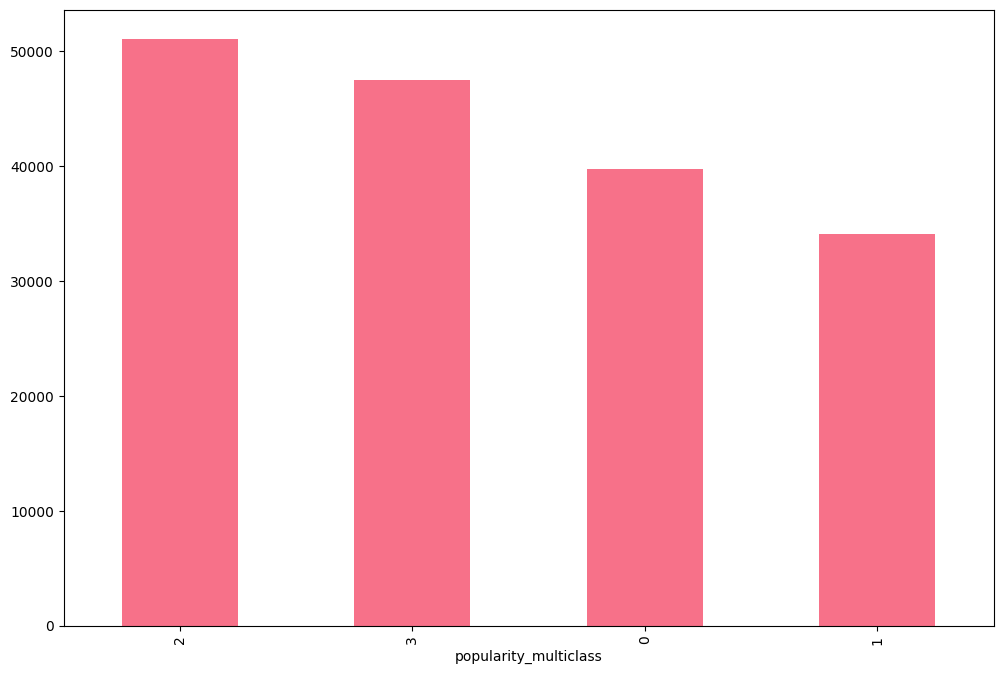

In [5]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [49]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity'] 



In [50]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,39729.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,34033.0,9.619575,6.125172,1.0,4.0,9.0,15.0,20.0
2,51035.0,30.747330,5.652618,21.0,26.0,31.0,36.0,40.0
3,47433.0,54.153163,9.966513,41.0,46.0,52.0,61.0,100.0


In [89]:
import xgboost
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_squared_error,r2_score
scaler = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X,y_multiclass_3,test_size=0.2)





In [90]:
X_train.shape

(137784, 71)

In [91]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
xg = xgboost.XGBRegressor(objective='reg:absoluteerror',
                               n_estimators=800,
                               learning_rate=0.05,
                               max_depth=4,
                               subsample=0.8,
                               col_sample_bytree=0.8,
                               reg_alpha=0.5,
                               reg_lambda=1.0,
                               min_child_weight=3)


In [92]:
from sklearn.compose import TransformedTargetRegressor
transformer = PowerTransformer(method='yeo-johnson')
mt = TransformedTargetRegressor(regressor=xg,transformer=transformer)
mt.fit(X_train_scaled,y_train)


,regressor,"XGBRegressor(...obs=None, ...)"
,transformer,PowerTransformer()
,func,None
,inverse_func,None
,check_inverse,True
,objective,'reg:absoluteerror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [93]:
y_pred = np.clip(np.round(mt.predict(X_test_scaled)),0,100)
r2= r2_score(y_test,y_pred)
r2

0.8483507633209229

In [94]:
y_pred.min()

np.float32(0.0)

In [95]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

8.50805950164795

In [96]:
y_pred.max()

np.float32(82.0)

In [87]:
y_test.max()

np.int64(96)

In [106]:
from sklearn.ensemble import RandomForestClassifier
xg1 = RandomForestClassifier(
                               n_estimators=800,           
                               max_depth=4,                           
                               )



In [107]:
xg1.fit(X_train_scaled,y_train)


,n_estimators,800
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
